# Attention sinks in Pythia: when do they emerge, and do they matter?

**Part 1 (descriptive):** measure how much attention goes to the first token at each training checkpoint, per layer and head, and line it up with the loss.

**Part 2 (causal):** block attention to the first token and measure the change in loss and in how similar token representations become (over-mixing), against a control that blocks a different position.

Runs on a free Colab GPU in roughly 10-20 minutes with the defaults. If pip changes `numpy` or `transformers`, restart the runtime once and run again from the top.

In [10]:
# Install/upgrade the packages used in both Part 1 and Part 2.
# IMPORTANT: after this cell finishes in Colab, if you previously imported
# transformer_lens in this runtime, use Runtime -> Restart session once.
!pip -q install -U transformers datasets accelerate "transformer-lens"

In [11]:
!pip uninstall -y transformer-lens transformers
!pip install -q "transformer-lens==2.16.1" "transformers==4.51.3" datasets accelerate

Found existing installation: transformer-lens 4.0.0
Uninstalling transformer-lens-4.0.0:
  Successfully uninstalled transformer-lens-4.0.0
Found existing installation: transformers 5.19.0
Uninstalling transformers-5.19.0:
  Successfully uninstalled transformers-5.19.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.29.0 requires huggingface-hub<3.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


### If you already ran the broken notebook in this Colab runtime

After running the installation cell above, use **Runtime → Restart session**
once, then run the notebook from the top.

This matters because Python can keep the previously imported/broken
`transformer_lens` package in memory even after `pip` upgrades it.

In [1]:
import gc
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

MODEL = "EleutherAI/pythia-160m"
TL_MODEL = "pythia-160m"

STEPS = [
    0, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1000, 2000, 4000,
    8000, 16000, 32000, 64000, 100000, 143000
]

SEQ_LEN = 256
N_SEQ = 64
BATCH = 16
PREPEND_BOS = False
SEED = 0

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
np.random.seed(SEED)

# We intentionally use FP32 for attention analysis.
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False

try:
    torch.set_float32_matmul_precision("highest")
except Exception:
    pass

print("device:", device)
print("torch:", torch.__version__)

device: cuda
torch: 2.11.0+cu130


In [2]:
def get_chunks(tok, n_seq=N_SEQ, seq_len=SEQ_LEN, seed=SEED):
    ds = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1",
        split="test"
    )

    text = "\n\n".join(t for t in ds["text"] if t.strip())
    ids = tok(text, return_tensors="pt").input_ids[0]

    body = seq_len - int(PREPEND_BOS)
    max_chunks = len(ids) // body

    g = torch.Generator().manual_seed(seed)
    pick = torch.randperm(max_chunks, generator=g)[:n_seq].tolist()

    chunks = torch.stack([
        ids[i * body:(i + 1) * body]
        for i in pick
    ])

    if PREPEND_BOS:
        # Pythia/GPT-NeoX commonly uses <|endoftext|> as the initial special token.
        bos_id = tok.bos_token_id
        if bos_id is None:
            bos_id = tok.eos_token_id
        if bos_id is None:
            raise ValueError("Tokenizer exposes neither bos_token_id nor eos_token_id.")

        bos = torch.full(
            (len(chunks), 1),
            bos_id,
            dtype=chunks.dtype
        )
        chunks = torch.cat([bos, chunks], dim=1)

    return chunks


tok = AutoTokenizer.from_pretrained(MODEL)
chunks = get_chunks(tok)

print("chunks:", chunks.shape)
print("first tokens:", tok.convert_ids_to_tokens(chunks[0, :12].tolist()))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


chunks: torch.Size([64, 256])
first tokens: ['ĠRi', 'oting', 'Ġbroke', 'Ġout', 'Ġafter', 'Ġthe', 'Ġrally', 'Ġ.', 'ĠPolice', 'Ġdrove', 'Ġriot', 'ers']


## Part 1: emergence across training

Sink mass = attention that query positions `t >= 1` place on key position 0, averaged over queries. Uniform attention over the causal window gives the baseline printed below.

In [3]:
def load_hf(step):
    """
    Load a Pythia training checkpoint in FP32 and force eager attention so
    output_attentions=True returns explicit attention matrices.
    """
    kw = dict(
        revision=f"step{step}",
        torch_dtype=torch.float32,
    )

    try:
        m = AutoModelForCausalLM.from_pretrained(
            MODEL,
            attn_implementation="eager",
            **kw
        )
    except (TypeError, ValueError):
        m = AutoModelForCausalLM.from_pretrained(
            MODEL,
            **kw
        )

    return m.to(device).eval()


def seq_loss(logits, x):
    l = F.cross_entropy(
        logits[:, :-1].reshape(-1, logits.size(-1)).float(),
        x[:, 1:].reshape(-1),
        reduction="none"
    )
    return l.view(len(x), -1).mean(1)


KEYS = 16


@torch.no_grad()
def measure(model, chunks):
    L = model.config.num_hidden_layers
    H = model.config.num_attention_heads

    head = torch.zeros(L, H)
    keyprof = torch.zeros(L, KEYS)

    per_seq = []
    nll = []

    for i in range(0, len(chunks), BATCH):
        x = chunks[i:i + BATCH].to(device)

        # Explicitly disable AMP/autocast.
        if device == "cuda":
            with torch.autocast(device_type="cuda", enabled=False):
                out = model(
                    x,
                    output_attentions=True,
                    use_cache=False,
                    return_dict=True
                )
        else:
            out = model(
                x,
                output_attentions=True,
                use_cache=False,
                return_dict=True
            )

        if out.attentions is None:
            raise RuntimeError(
                "Model returned no attention tensors. "
                "Make sure attn_implementation='eager' is being used."
            )

        nll.append(seq_loss(out.logits, x).cpu())
        rows = []

        for li, a in enumerate(out.attentions):
            a = a.float()

            if not torch.isfinite(a).all():
                raise RuntimeError(
                    f"NaN/Inf detected in attention at layer {li}. "
                    "The model must be loaded in FP32."
                )

            # Mean attention from later queries to absolute key position 0.
            s = a[:, :, 1:, 0].mean(dim=2)  # [batch, head]

            head[li] += s.sum(dim=0).cpu()
            rows.append(s.mean(dim=1).cpu())

            # Attention profile for the first KEYS positions from later queries.
            keyprof[li] += (
                a[:, :, 2 * KEYS:, :KEYS]
                .mean(dim=(1, 2))
                .sum(dim=0)
                .cpu()
            )

        per_seq.append(torch.stack(rows, dim=1))

    n = len(chunks)

    return (
        head / n,
        keyprof / n,
        torch.cat(per_seq),
        torch.cat(nll)
    )


uniform = float(
    np.mean([1 / (t + 1) for t in range(1, SEQ_LEN)])
)

print(f"uniform-attention baseline: {uniform:.4f}")

uniform-attention baseline: 0.0201


In [4]:
res = {}

for step in STEPS:
    model = load_hf(step)

    head, keyprof, per_seq, nll = measure(
        model,
        chunks
    )

    res[step] = dict(
        head=head.numpy(),
        keyprof=keyprof.numpy(),
        per_seq=per_seq.numpy(),
        nll=nll.numpy()
    )

    print(
        f"step {step:>6}  "
        f"loss {nll.mean():.3f}  "
        f"sink mass {per_seq.mean():.3f}  "
        f"max head {head.max():.3f}"
    )

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


np.savez(
    "part1_results.npz",
    steps=np.array(STEPS),
    head=np.stack([res[s]["head"] for s in STEPS]),
    keyprof=np.stack([res[s]["keyprof"] for s in STEPS]),
    per_seq=np.stack([res[s]["per_seq"] for s in STEPS]),
    nll=np.stack([res[s]["nll"] for s in STEPS])
)

step      0  loss 11.059  sink mass 0.020  max head 0.022
step      1  loss 11.059  sink mass 0.020  max head 0.022
step      2  loss 11.058  sink mass 0.020  max head 0.022
step      4  loss 11.022  sink mass 0.020  max head 0.022
step      8  loss 10.867  sink mass 0.020  max head 0.022
step     16  loss 10.509  sink mass 0.020  max head 0.022
step     32  loss 10.045  sink mass 0.020  max head 0.022
step     64  loss 9.418  sink mass 0.020  max head 0.022
step    128  loss 8.308  sink mass 0.019  max head 0.022
step    256  loss 7.539  sink mass 0.016  max head 0.022
step    512  loss 6.581  sink mass 0.014  max head 0.023
step   1000  loss 5.362  sink mass 0.018  max head 0.045
step   2000  loss 4.606  sink mass 0.032  max head 0.103
step   4000  loss 4.218  sink mass 0.072  max head 0.305
step   8000  loss 4.009  sink mass 0.171  max head 0.610
step  16000  loss 3.862  sink mass 0.221  max head 0.665
step  32000  loss 3.781  sink mass 0.261  max head 0.685
step  64000  loss 3.743 

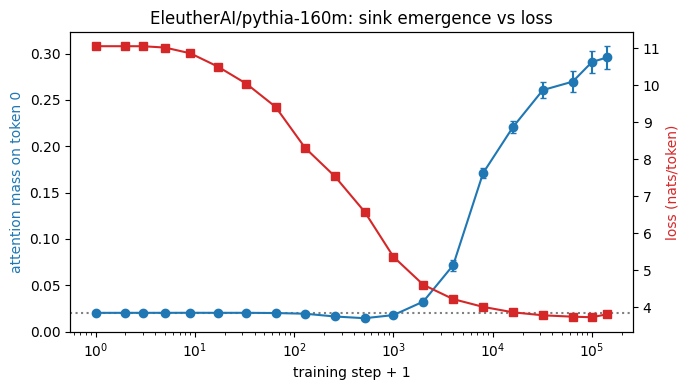

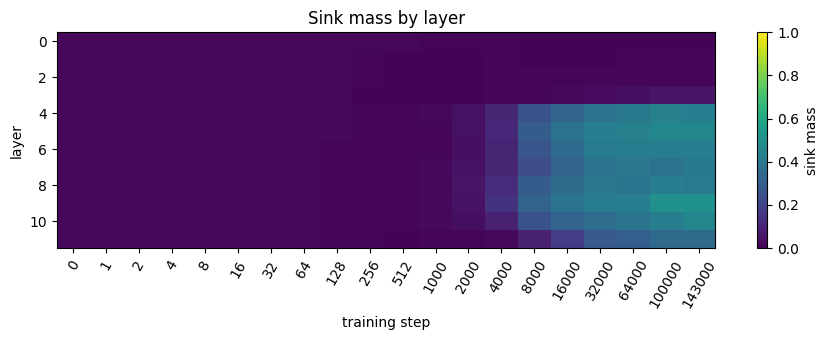

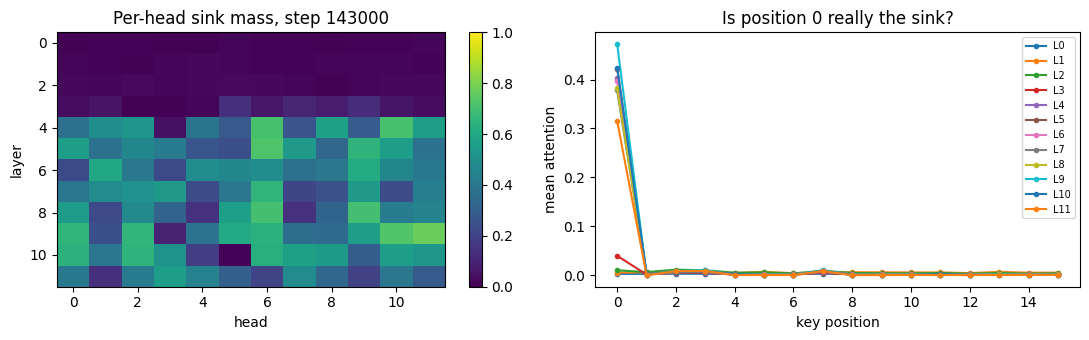

In [5]:
per_seq = np.stack([res[s]["per_seq"] for s in STEPS])   # [ckpt, seq, layer]
nll = np.stack([res[s]["nll"] for s in STEPS])           # [ckpt, seq]
xs = np.array(STEPS) + 1                                 # +1 so step 0 shows on a log axis
n = per_seq.shape[1]

m = per_seq.mean((1, 2)); se = per_seq.mean(2).std(1, ddof=1) / np.sqrt(n)
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(xs, m, yerr=se, marker="o", color="C0", capsize=2)
ax.axhline(uniform, ls=":", color="gray")
ax.set_xscale("log"); ax.set_xlabel("training step + 1")
ax.set_ylabel("attention mass on token 0", color="C0")
ax2 = ax.twinx()
ax2.errorbar(xs, nll.mean(1), yerr=nll.std(1, ddof=1) / np.sqrt(n), marker="s", color="C3", capsize=2)
ax2.set_ylabel("loss (nats/token)", color="C3")
ax.set_title(f"{MODEL}: sink emergence vs loss")
fig.tight_layout(); fig.savefig("fig1_emergence.png", dpi=200); plt.show()

by_layer = per_seq.mean(1).T                              # [layer, ckpt]
fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(by_layer, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(STEPS))); ax.set_xticklabels(STEPS, rotation=60)
ax.set_xlabel("training step"); ax.set_ylabel("layer")
fig.colorbar(im, label="sink mass"); ax.set_title("Sink mass by layer")
fig.tight_layout(); fig.savefig("fig2_layer_heatmap.png", dpi=200); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
im = axes[0].imshow(res[STEPS[-1]]["head"], aspect="auto", cmap="viridis", vmin=0, vmax=1)
axes[0].set_xlabel("head"); axes[0].set_ylabel("layer")
axes[0].set_title(f"Per-head sink mass, step {STEPS[-1]}"); fig.colorbar(im, ax=axes[0])
for li, row in enumerate(res[STEPS[-1]]["keyprof"]):
    axes[1].plot(range(KEYS), row, marker=".", label=f"L{li}")
axes[1].set_xlabel("key position"); axes[1].set_ylabel("mean attention")
axes[1].set_title("Is position 0 really the sink?"); axes[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig("fig3_heads_positions.png", dpi=200); plt.show()

In [6]:
THRESH = 0.3   # a layer "has a sink" once its mean sink mass passes this
print(f"First checkpoint where sink mass > {THRESH}:")
for li, row in enumerate(by_layer):
    hit = [s for s, v in zip(STEPS, row) if v > THRESH]
    print(f"  layer {li}: {('step ' + str(hit[0])) if hit else 'never'}   (final {row[-1]:.3f})")

First checkpoint where sink mass > 0.3:
  layer 0: never   (final 0.009)
  layer 1: never   (final 0.013)
  layer 2: never   (final 0.019)
  layer 3: never   (final 0.060)
  layer 4: step 16000   (final 0.433)
  layer 5: step 16000   (final 0.458)
  layer 6: step 16000   (final 0.429)
  layer 7: step 16000   (final 0.405)
  layer 8: step 16000   (final 0.417)
  layer 9: step 8000   (final 0.504)
  layer 10: step 16000   (final 0.459)
  layer 11: step 64000   (final 0.347)


## Part 2: are sinks causally useful?

Intervention: set the pre-softmax attention score from every later query to one key position to `-inf` in chosen layers. `key_pos=0` blocks the sink; `CONTROL_POS` blocks an ordinary token, so any generic cost of removing one key is accounted for.

Over-mixing metric: mean pairwise cosine similarity between token representations in the residual stream after each layer (position 0 excluded). If sinks prevent over-mixing, blocking them should raise it.

In [7]:
# TransformerLens import
from transformer_lens import HookedTransformer

CONTROL_POS = 8


def load_tl(step=None):
    """
    Load the exact Pythia HF checkpoint, patch compatibility fields
    expected by older TransformerLens, then convert it to HookedTransformer.
    """
    if step is None:
        step = STEPS[-1]

    hf = AutoModelForCausalLM.from_pretrained(
        MODEL,
        revision=f"step{step}",
        torch_dtype=torch.float32,
    ).to(device).eval()

    # ---------------------------------------------------------
    # Compatibility fix for newer Hugging Face GPTNeoXConfig
    # ---------------------------------------------------------
    if not hasattr(hf.config, "rotary_pct"):
        hf.config.rotary_pct = 0.25

    print(
        f"Loading TL checkpoint step={step} | "
        f"rotary_pct={hf.config.rotary_pct}"
    )

    try:
        tl_model = HookedTransformer.from_pretrained_no_processing(
            TL_MODEL,
            hf_model=hf,
            device=device,
            dtype=torch.float32,
        )

    except TypeError:
        # Fallback for TransformerLens versions that do not accept dtype here.
        tl_model = HookedTransformer.from_pretrained_no_processing(
            TL_MODEL,
            hf_model=hf,
            device=device,
        )

        tl_model = tl_model.to(torch.float32)

    tl_model.eval()

    del hf
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return tl_model


def block_hook(key_pos):
    """
    Prevent later query positions from attending to one selected key position.

    scores shape:
        [batch, head, query_position, key_position]
    """
    def fn(scores, hook):

        scores = scores.clone()

        if key_pos < scores.shape[-1]:

            # Queries after key_pos are forbidden from attending to it.
            scores[
                :,
                :,
                key_pos + 1:,
                key_pos
            ] = float("-inf")

        return scores

    return fn


@torch.no_grad()
def run(
    model,
    chunks,
    block_layers=(),
    key_pos=0
):
    """
    Run Pythia and optionally block attention to key_pos
    in selected transformer layers.

    Returns:
        losses: per-sequence next-token loss
        sims:   residual-stream pairwise cosine similarity
                for every transformer layer
    """

    nL = model.cfg.n_layers

    resid = {}

    # ---------------------------------------------------------
    # Hook for saving residual-stream activations
    # ---------------------------------------------------------
    def grab(layer):

        def fn(act, hook):

            resid[layer] = act.detach()

            return act

        return fn

    # ---------------------------------------------------------
    # Attention-blocking hooks
    # ---------------------------------------------------------
    hooks = [
        (
            f"blocks.{layer}.attn.hook_attn_scores",
            block_hook(key_pos)
        )
        for layer in block_layers
    ]

    # ---------------------------------------------------------
    # Residual-stream capture hooks
    # ---------------------------------------------------------
    hooks += [
        (
            f"blocks.{layer}.hook_resid_post",
            grab(layer)
        )
        for layer in range(nL)
    ]

    losses = []
    sims = []

    # ---------------------------------------------------------
    # Run dataset in batches
    # ---------------------------------------------------------
    for i in range(
        0,
        len(chunks),
        BATCH
    ):

        x = chunks[
            i:i + BATCH
        ].to(device)

        logits = model.run_with_hooks(
            x,
            return_type="logits",
            fwd_hooks=hooks,
        )

        # Next-token prediction loss
        losses.append(
            seq_loss(
                logits,
                x
            ).cpu()
        )

        layer_sims = []

        # -----------------------------------------------------
        # Representation similarity for each transformer layer
        # -----------------------------------------------------
        for layer in range(nL):

            r = resid[layer]

            # Ignore first position for this similarity metric.
            r = r[:, 1:].float()

            # Normalize each token representation.
            r = F.normalize(
                r,
                dim=-1
            )

            # Pairwise cosine similarity matrix
            #
            # [B,T,D] @ [B,D,T]
            #      -> [B,T,T]
            g = (
                r
                @ r.transpose(1, 2)
            )

            T = g.size(1)

            # Remove diagonal self-similarity.
            pairwise = (
                g.sum(dim=(1, 2))
                - T
            ) / (
                T * (T - 1)
            )

            layer_sims.append(
                pairwise
            )

        sims.append(
            torch.stack(
                layer_sims,
                dim=1
            ).cpu()
        )

    losses = torch.cat(
        losses
    ).numpy()

    sims = torch.cat(
        sims
    ).numpy()

    return losses, sims


# ============================================================
# Load final Pythia checkpoint
# ============================================================

tl = load_tl()

nL = tl.cfg.n_layers

print(
    "TransformerLens model loaded successfully."
)

print(
    "Number of layers:",
    nL
)


# ============================================================
# Baseline: no attention blocking
# ============================================================

base_loss, base_sim = run(
    tl,
    chunks
)

print(
    f"Baseline loss: "
    f"{base_loss.mean():.3f}"
)

print(
    f"Part 1 final-checkpoint loss: "
    f"{res[STEPS[-1]]['nll'].mean():.3f}"
)

print(
    "These two values should be reasonably close."
)

Loading TL checkpoint step=143000 | rotary_pct=0.25
Loaded pretrained model pythia-160m into HookedTransformer
TransformerLens model loaded successfully.
Number of layers: 12
Baseline loss: 3.811
Part 1 final-checkpoint loss: 3.811
These two values should be reasonably close.


In [8]:
def paired(a, b):
    d = a - b
    return d.mean(), d.std(ddof=1) / np.sqrt(len(d))

conds = [(f"L{l}", [l]) for l in range(nL)] + [("all", list(range(nL)))]
out = {}
for name, layers in conds:
    out[name] = dict(sink=run(tl, chunks, layers, 0), ctrl=run(tl, chunks, layers, CONTROL_POS))
    ds, es = paired(out[name]["sink"][0], base_loss)
    dc, ec = paired(out[name]["ctrl"][0], base_loss)
    print(f"block {name:>3}:  sink dLoss {ds:+.3f} +/- {es:.3f}   control dLoss {dc:+.3f} +/- {ec:.3f}")

block  L0:  sink dLoss +0.008 +/- 0.002   control dLoss +0.001 +/- 0.001
block  L1:  sink dLoss +0.005 +/- 0.001   control dLoss +0.001 +/- 0.000
block  L2:  sink dLoss +0.004 +/- 0.001   control dLoss +0.001 +/- 0.001
block  L3:  sink dLoss +0.023 +/- 0.002   control dLoss +0.000 +/- 0.000
block  L4:  sink dLoss +0.341 +/- 0.020   control dLoss +0.001 +/- 0.000
block  L5:  sink dLoss +0.097 +/- 0.007   control dLoss +0.000 +/- 0.000
block  L6:  sink dLoss +0.074 +/- 0.005   control dLoss +0.000 +/- 0.000
block  L7:  sink dLoss +0.040 +/- 0.003   control dLoss +0.000 +/- 0.000
block  L8:  sink dLoss +0.023 +/- 0.003   control dLoss +0.000 +/- 0.000
block  L9:  sink dLoss +0.017 +/- 0.002   control dLoss +0.000 +/- 0.000
block L10:  sink dLoss +0.001 +/- 0.001   control dLoss +0.000 +/- 0.000
block L11:  sink dLoss +0.009 +/- 0.002   control dLoss +0.000 +/- 0.000
block all:  sink dLoss +0.016 +/- 0.004   control dLoss +0.015 +/- 0.002


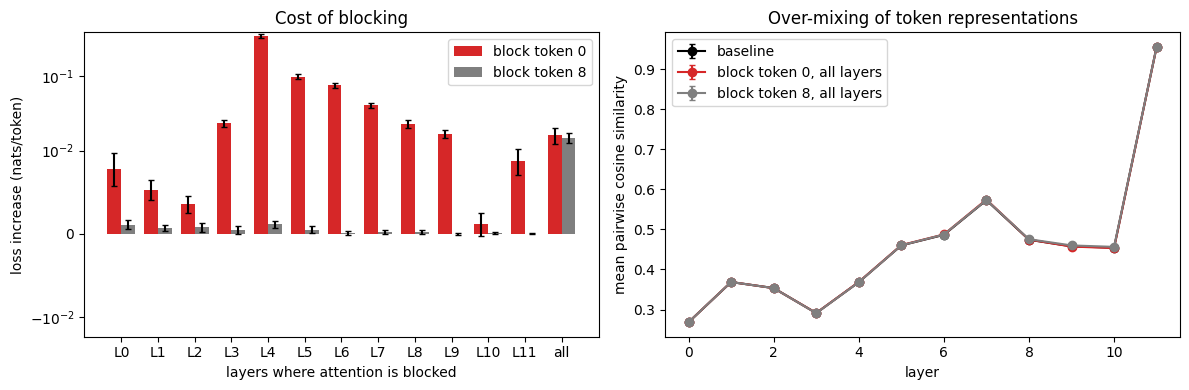

In [9]:
names = [c[0] for c in conds]
x = np.arange(len(names)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, (key, lab, col) in enumerate([("sink", "block token 0", "C3"), ("ctrl", f"block token {CONTROL_POS}", "C7")]):
    st = [paired(out[nm][key][0], base_loss) for nm in names]
    axes[0].bar(x + (k - 0.5) * w, [s[0] for s in st], w, yerr=[s[1] for s in st], capsize=2, label=lab, color=col)
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_xlabel("layers where attention is blocked"); axes[0].set_ylabel("loss increase (nats/token)")
axes[0].set_yscale("symlog", linthresh=0.01); axes[0].legend(); axes[0].set_title("Cost of blocking")

sq = np.sqrt(len(base_sim))
for arr, lab, col in [(base_sim, "baseline", "k"),
                      (out["all"]["sink"][1], "block token 0, all layers", "C3"),
                      (out["all"]["ctrl"][1], f"block token {CONTROL_POS}, all layers", "C7")]:
    axes[1].errorbar(range(nL), arr.mean(0), yerr=arr.std(0, ddof=1) / sq, marker="o", capsize=2, label=lab, color=col)
axes[1].set_xlabel("layer"); axes[1].set_ylabel("mean pairwise cosine similarity")
axes[1].legend(); axes[1].set_title("Over-mixing of token representations")
fig.tight_layout(); fig.savefig("fig4_causal.png", dpi=200); plt.show()

### Linking the two parts

Does blocking only start to hurt once the sink has formed? Pick checkpoints from before, during and after the emergence you saw in Figure 1.

Loading TL checkpoint step=512 | rotary_pct=0.25
Loaded pretrained model pythia-160m into HookedTransformer
step    512: sink dLoss +0.008   control dLoss +0.003
Loading TL checkpoint step=2000 | rotary_pct=0.25
Loaded pretrained model pythia-160m into HookedTransformer
step   2000: sink dLoss +0.009   control dLoss +0.010
Loading TL checkpoint step=8000 | rotary_pct=0.25
Loaded pretrained model pythia-160m into HookedTransformer
step   8000: sink dLoss +0.022   control dLoss +0.013
Loading TL checkpoint step=32000 | rotary_pct=0.25
Loaded pretrained model pythia-160m into HookedTransformer
step  32000: sink dLoss +0.020   control dLoss +0.015
Loading TL checkpoint step=143000 | rotary_pct=0.25
Loaded pretrained model pythia-160m into HookedTransformer
step 143000: sink dLoss +0.016   control dLoss +0.015


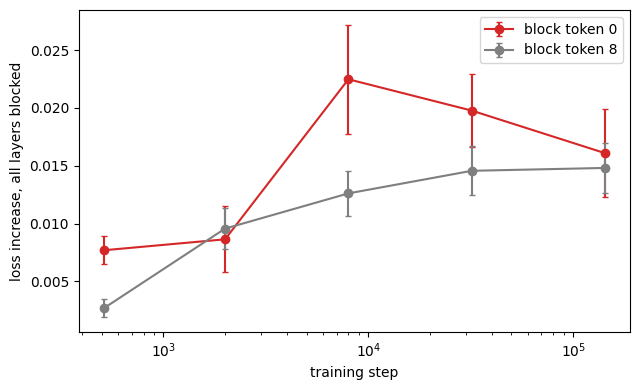

In [10]:
CAUSAL_STEPS = [512, 2000, 8000, 32000, 143000]
allL = list(range(nL))
rows = []

for step in CAUSAL_STEPS:
    m = load_tl(step)

    b, _ = run(m, chunks)
    s, _ = run(m, chunks, allL, 0)
    c, _ = run(m, chunks, allL, CONTROL_POS)

    rows.append(
        (
            paired(s, b),
            paired(c, b)
        )
    )

    print(
        f"step {step:>6}: "
        f"sink dLoss {rows[-1][0][0]:+.3f}   "
        f"control dLoss {rows[-1][1][0]:+.3f}"
    )

    del m
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


fig, ax = plt.subplots(figsize=(6.5, 4))

ax.errorbar(
    CAUSAL_STEPS,
    [r[0][0] for r in rows],
    yerr=[r[0][1] for r in rows],
    marker="o",
    color="C3",
    capsize=2,
    label="block token 0"
)

ax.errorbar(
    CAUSAL_STEPS,
    [r[1][0] for r in rows],
    yerr=[r[1][1] for r in rows],
    marker="o",
    color="C7",
    capsize=2,
    label=f"block token {CONTROL_POS}"
)

ax.set_xscale("log")
ax.set_xlabel("training step")
ax.set_ylabel("loss increase, all layers blocked")
ax.legend()

fig.tight_layout()
fig.savefig("fig5_causal_over_training.png", dpi=200)
plt.show()